In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install timm peft scikit-learn matplotlib seaborn grad-cam -q

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 29.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import os, pickle, random, io, json
from pathlib import Path
import torch
import torch.nn as nn
import torchvision.models as tvm
import timm
from peft import LoraConfig, get_peft_model
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, Subset
from PIL import Image
import torchvision.transforms.functional as TF
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [ ]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [ ]:
PROJECT_DIR = Path("/content/drive/MyDrive/Indian_Food_Research")
SPLITS_DIR = PROJECT_DIR / "splits"
RESULTS_DIR = PROJECT_DIR / "results"
MODELS_DIR = PROJECT_DIR / "models"
FIGURES_DIR = PROJECT_DIR / "figures"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
for d in [RESULTS_DIR, MODELS_DIR, FIGURES_DIR, OUTPUTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR, "| exists:", PROJECT_DIR.exists())

PROJECT_DIR: /content/drive/MyDrive/Indian_Food_Research | exists: True


In [ ]:
train_idx = pickle.load(open(SPLITS_DIR / "train_idx.pkl", "rb"))
val_idx = pickle.load(open(SPLITS_DIR / "val_idx.pkl", "rb"))
test_idx = pickle.load(open(SPLITS_DIR / "test_idx.pkl", "rb"))
print(f"Train: {len(train_idx)} Val: {len(val_idx)} Test: {len(test_idx)}")
assert len(set(train_idx) & set(test_idx)) == 0, "Train/test overlap!"
assert len(set(val_idx) & set(test_idx)) == 0, "Val/test overlap!"
print("Split integrity check passed ✓")

Train: 3204 Val: 687 Test: 687
Split integrity check passed ✓


In [ ]:
IMG_SIZE = 224
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

In [ ]:
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])
# raw_tf: no normalisation — we apply degradation first, then normalise manually
raw_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])
normalize = transforms.Normalize(MEAN, STD)

In [ ]:
DATASET_PATH = PROJECT_DIR / "datasets" / "CompressedDataset"
full_ds = datasets.ImageFolder(str(DATASET_PATH))
class_names = full_ds.classes
num_classes = len(class_names)
print(f"Classes: {num_classes} Total images: {len(full_ds)}")

class TransformedSubset(Dataset):
    def __init__(self, base_ds, indices, transform):
        self.base_ds = base_ds
        self.indices = indices
        self.transform = transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        path, label = self.base_ds.samples[self.indices[i]]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label

Classes: 100 Total images: 4578


In [ ]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cuda


In [ ]:
def build_resnet50_scratch(num_classes):
    model = tvm.resnet50(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [ ]:
def build_dinov2_linear_probe(num_classes):
    model = timm.create_model('vit_base_patch14_dinov2', pretrained=False,
                               num_classes=num_classes, img_size=224)
    for n, p in model.named_parameters():
        if 'head' not in n:
            p.requires_grad = False
    return model

In [ ]:
def build_dinov2_lora(num_classes, r=8, alpha=16, dropout=0.1):
    # MUST match training notebook exactly: pretrained=True + modules_to_save=["head"]
    backbone = timm.create_model('vit_base_patch14_dinov2', pretrained=True,
                                  num_classes=num_classes, img_size=224)
    config = LoraConfig(r=r, lora_alpha=alpha, target_modules=['qkv'],
                         lora_dropout=dropout, modules_to_save=["head"])
    model = get_peft_model(backbone, config)
    return model

def build_dinov2_full_ft(num_classes):
    model = timm.create_model('vit_base_patch14_dinov2', pretrained=False,
                               num_classes=num_classes, img_size=224)
    for p in model.parameters():
        p.requires_grad = True
    return model

In [ ]:
@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = model(imgs).argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return correct / total

In [ ]:
# ── ResNet50 (scratch) ─────────────────────────────────────────────
resnet_model = build_resnet50_scratch(num_classes)
resnet_path = MODELS_DIR / 'resnet50_scratch_100pct.pt'
if resnet_path.exists():
    resnet_model.load_state_dict(torch.load(str(resnet_path), map_location=DEVICE))
    print("ResNet50_scratch weights loaded ✓")
resnet_model = resnet_model.to(DEVICE)
resnet_model.eval()
print("ResNet50_scratch model initialized and moved to device.")

ResNet50_scratch weights loaded ✓
ResNet50_scratch model initialized and moved to device.


In [ ]:
# ── DINOv2 Linear Probe ────────────────────────────────────────────
linprobe_model = build_dinov2_linear_probe(num_classes)
linprobe_path = MODELS_DIR / 'linear_probe_100pct.pt'
if linprobe_path.exists():
    linprobe_model.load_state_dict(torch.load(str(linprobe_path), map_location=DEVICE))
    print("DINOv2_linear_probe weights loaded ✓")
linprobe_model = linprobe_model.to(DEVICE)
linprobe_model.eval()
print("DINOv2_linear_probe model initialized and moved to device.")

DINOv2_linear_probe weights loaded ✓
DINOv2_linear_probe model initialized and moved to device.


In [ ]:
!pip uninstall torchao -y -q
!pip install -q torchao==0.16.0 --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 55.4 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
MODELS_DIR = Path("/content/drive/MyDrive/Indian_Food_Research/models")
for f in sorted(MODELS_DIR.iterdir()):
    print(f.name, f.stat().st_size / 1e6, "MB")

best_resnet50.pth 95.171683 MB
dinov2_lora_full.pth 344.788795 MB
final_resnet50.pth 95.172009 MB
full_finetune_100pct.pt 343.276061 MB
linear_probe_100pct.pt 343.275879 MB
lora_adapter_100pct 0.004096 MB
resnet50_scratch_100pct.pt 95.175007 MB


In [ ]:
from pathlib import Path
folder = Path("/content/drive/MyDrive/Indian_Food_Research/models/lora_adapter_100pct")
for f in folder.iterdir():
    print(f.name, f.stat().st_size / 1e6, "MB")

README.md 0.005074 MB
adapter_config.json 0.001079 MB
adapter_model.safetensors 1.18244 MB


In [ ]:
import json
CKPT_PATH = Path("/content/drive/MyDrive/Indian_Food_Research/results/label_efficiency_checkpoints.json")
if CKPT_PATH.exists():
    with open(CKPT_PATH) as f:
        results = json.load(f)
    for r in results:
        print(r['method'], r['fraction'], f"{r['test_acc']:.4f}")
else:
    print("No checkpoint file found")

resnet50_scratch 0.1 0.1048
linear_probe 0.1 0.7889
lora 0.1 0.8020
full_finetune 0.1 0.6477
resnet50_scratch 0.25 0.2606
linear_probe 0.25 0.8821
lora 0.25 0.8894
full_finetune 0.25 0.8370
resnet50_scratch 0.5 0.4818
linear_probe 0.5 0.9243
lora 0.5 0.9403
full_finetune 0.5 0.8981
resnet50_scratch 1.0 0.5924
linear_probe 1.0 0.9447
full_finetune 1.0 0.9461
lora 1.0 0.9592


In [ ]:
# ── DINOv2 LoRA  load the full state dict saved by the training notebook ──
lora_model = build_dinov2_lora(num_classes)

lora_ckpt_path = MODELS_DIR / 'dinov2_lora_full.pth'
if not lora_ckpt_path.exists():
    raise FileNotFoundError(
        f"{lora_ckpt_path} not found. This should be the full state_dict "
        f"(adapters + head) saved by the label-efficiency training notebook."
    )

state_dict = torch.load(str(lora_ckpt_path), map_location=DEVICE)
missing, unexpected = lora_model.load_state_dict(state_dict, strict=True)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Missing keys: []
Unexpected keys: []


In [ ]:
# strict=True will raise on its own if anything doesn't match, so if we get here it's clean

lora_model = lora_model.eval().to(DEVICE)
print("LoRA loaded ✓ (full state dict, head included)")

eval_lora_model = lora_model
print("Full LoRA model 'eval_lora_model' now refers to the 'lora_model' loaded previously.")

LoRA loaded ✓ (full state dict, head included)
Full LoRA model 'eval_lora_model' now refers to the 'lora_model' loaded previously.


In [ ]:
# ── Sanity check: clean accuracy should be close to training-time test_acc ──
eval_test_ds = TransformedSubset(full_ds, test_idx, eval_tf)
eval_test_loader = DataLoader(eval_test_ds, batch_size=32, shuffle=False, num_workers=2)
clean_acc = evaluate_model(lora_model, eval_test_loader)
print(f"LoRA clean test accuracy check: {clean_acc*100:.2f}%")
if clean_acc < 0.5:
    raise RuntimeError(
        "LoRA clean accuracy is still suspiciously low — do not proceed to "
        "robustness eval. Something is still mismatched between training and eval."
    )

LoRA clean test accuracy check: 95.92%


In [ ]:
# ── Degradation functions ──────────────────────────────────────────
def jpeg_compress(img_tensor, quality=20):
    """CHW tensor [0,1] → JPEG compressed → CHW tensor [0,1]"""
    pil = TF.to_pil_image(img_tensor.clamp(0, 1))
    buf = io.BytesIO()
    pil.save(buf, format='JPEG', quality=quality)
    buf.seek(0)
    return TF.to_tensor(Image.open(buf).convert('RGB'))

def gaussian_noise(img_tensor, std=0.1):
    return (img_tensor + torch.randn_like(img_tensor) * std).clamp(0, 1)

_blur = transforms.GaussianBlur(kernel_size=15, sigma=(3, 5))

In [ ]:
degradations = {
    'clean': None,
    'blur': lambda x: _blur(x),
    'jpeg': lambda x: jpeg_compress(x, quality=20),
    'low_bright': lambda x: (x * 0.3).clamp(0, 1),
    'high_bright': lambda x: (x * 2.5).clamp(0, 1),
    'noise': lambda x: gaussian_noise(x, std=0.1),
    'combined': lambda x: jpeg_compress(
        gaussian_noise(_blur(x), std=0.08), quality=25),
}
print("Degradations ready:", list(degradations.keys()))

Degradations ready: ['clean', 'blur', 'jpeg', 'low_bright', 'high_bright', 'noise', 'combined']


In [ ]:
def evaluate_degraded(model, degradation_fn):
    """Evaluate model on test set with degradation applied before normalise."""
    model.eval()
    raw_ds = datasets.ImageFolder(str(DATASET_PATH), transform=raw_tf)
    loader = DataLoader(Subset(raw_ds, test_idx),
                         batch_size=32, shuffle=False, num_workers=2)
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in tqdm(loader, leave=False):
            if degradation_fn is not None:
                imgs = torch.stack([degradation_fn(x) for x in imgs])
            imgs = normalize(imgs).to(DEVICE)
            labels = labels.to(DEVICE)
            preds = model(imgs).argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return round((correct / total) * 100, 2)

In [ ]:
models_dict = {
    'ResNet50_scratch': resnet_model,
    'DINOv2_linear_probe': linprobe_model,
    'DINOv2_LoRA': lora_model,
}

In [ ]:
rob_results = {}
for model_name, model in models_dict.items():
    rob_results[model_name] = {}
    for deg_name, deg_fn in degradations.items():
        acc = evaluate_degraded(model, deg_fn)
        rob_results[model_name][deg_name] = acc
        print(f"{model_name:28s} | {deg_name:12s}: {acc:.2f}%")
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

ResNet50_scratch             | clean       : 59.24%


ResNet50_scratch             | blur        : 14.26%


ResNet50_scratch             | jpeg        : 58.22%


ResNet50_scratch             | low_bright  : 4.22%


ResNet50_scratch             | high_bright : 12.37%


...

DINOv2_LoRA                  | jpeg        : 93.74%


DINOv2_LoRA                  | low_bright  : 95.49%


DINOv2_LoRA                  | high_bright : 90.25%


DINOv2_LoRA                  | noise       : 90.10%


DINOv2_LoRA                  | combined    : 37.26%


In [ ]:
df_rob = pd.DataFrame(rob_results).T
df_rob.to_csv(str(OUTPUTS_DIR / 'table7_robustness.csv'))
print("\nTable 7 saved ✓")
print(df_rob.to_string())

col_order = ['clean', 'blur', 'jpeg', 'low_bright', 'high_bright', 'noise', 'combined']
col_labels = ['Clean', 'Blur', 'JPEG\nq=20', 'Low\nBright', 'High\nBright', 'Noise', 'Combined']
df_plot = df_rob[col_order].copy()
df_plot.columns = col_labels


Table 7 saved ✓
                     clean   blur   jpeg  low_bright  high_bright  noise  combined
ResNet50_scratch     59.24  14.26  58.22        4.22        12.37  27.07     18.78
DINOv2_linear_probe  94.47  59.83  91.70       94.18        89.96  87.92     22.85
DINOv2_LoRA          95.92  69.87  93.74       95.49        90.25  90.10     37.26


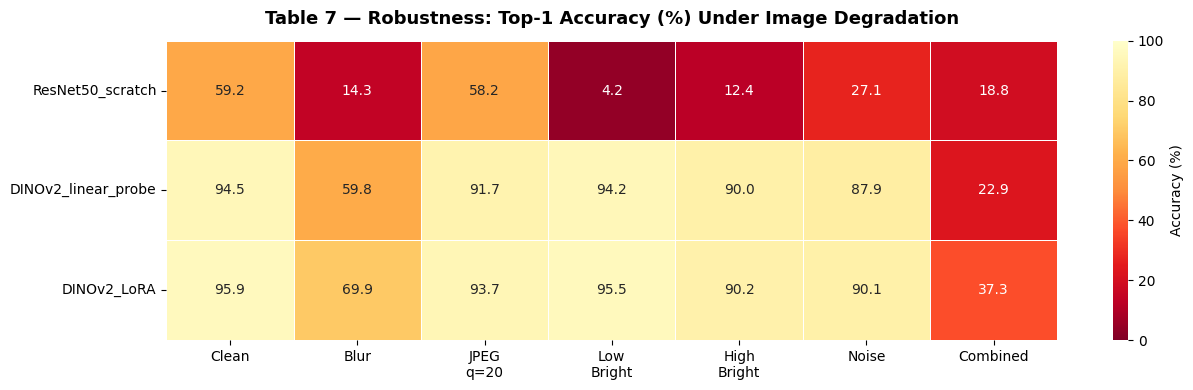

Heatmap saved ✓


In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    df_plot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    ax=ax,
    vmin=0,
    vmax=100,
    cbar_kws={'label': 'Accuracy (%)'}
)
ax.set_title('Table 7 — Robustness: Top-1 Accuracy (%) Under Image Degradation',
              pad=12, fontsize=13, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / 'table7_robustness_heatmap.png'), dpi=300, bbox_inches='tight')
plt.savefig(str(OUTPUTS_DIR / 'table7_robustness_heatmap.pdf'), dpi=300, bbox_inches='tight')
plt.show()
print("Heatmap saved ✓")

In [ ]:
# Accuracy drop table
df_drop = pd.DataFrame(index=df_rob.index)
for col in col_order[1:]:
    df_drop[f'drop_{col}'] = (df_rob['clean'] - df_rob[col]).round(2)
df_drop.to_csv(str(OUTPUTS_DIR / 'table7_accuracy_drop.csv'))
print("\nAccuracy Drop (clean − degraded, percentage points):")
print(df_drop.to_string())


Accuracy Drop (clean − degraded, percentage points):
                     drop_blur  drop_jpeg  drop_low_bright  drop_high_bright  drop_noise  drop_combined
ResNet50_scratch         44.98       1.02            55.02             46.87       32.17          40.46
DINOv2_linear_probe      34.64       2.77             0.29              4.51        6.55          71.62
DINOv2_LoRA              26.05       2.18             0.43              5.67        5.82          58.66


In [ ]:
# ── Grad-CAM setup ──────────────────────────────────────────────────
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

def reshape_transform_vit(tensor, height=16, width=16):
    """Reshape ViT [B, N+1, C] patch tokens → [B, C, H, W] for Grad-CAM."""
    result = tensor[:, 1:, :]  # drop CLS token
    result = result.reshape(result.size(0), height, width, result.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

def denorm_to_numpy(img_tensor):
    """CHW normalised tensor → HWC float32 numpy [0,1] for display."""
    mean = torch.tensor(MEAN).view(3, 1, 1)
    std = torch.tensor(STD).view(3, 1, 1)
    return (img_tensor.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

def gradcam_resnet(model, img_tensor, target_cls):
    model.eval()
    cam = GradCAM(model=model, target_layers=[model.layer4[-1]])
    grayscale = cam(
        input_tensor=img_tensor.unsqueeze(0).to(DEVICE),
        targets=[ClassifierOutputTarget(target_cls)]
    )[0]
    rgb = denorm_to_numpy(img_tensor)
    overlay = show_cam_on_image(rgb, grayscale, use_rgb=True)
    return rgb, overlay

def gradcam_vit(model, img_tensor, target_layer, target_cls):
    model.eval()
    cam = GradCAM(
        model=model,
        target_layers=[target_layer],
        reshape_transform=reshape_transform_vit
    )
    grayscale = cam(
        input_tensor=img_tensor.unsqueeze(0).to(DEVICE),
        targets=[ClassifierOutputTarget(target_cls)]
    )[0]
    rgb = denorm_to_numpy(img_tensor)
    overlay = show_cam_on_image(rgb, grayscale, use_rgb=True)
    return rgb, overlay

Grad-CAM helpers ready ✓
  ResNet target : model.layer4[-1]
  LoRA target   : lora_model.base_model.model.blocks[-1].norm1


Generated predictions for 687 samples.


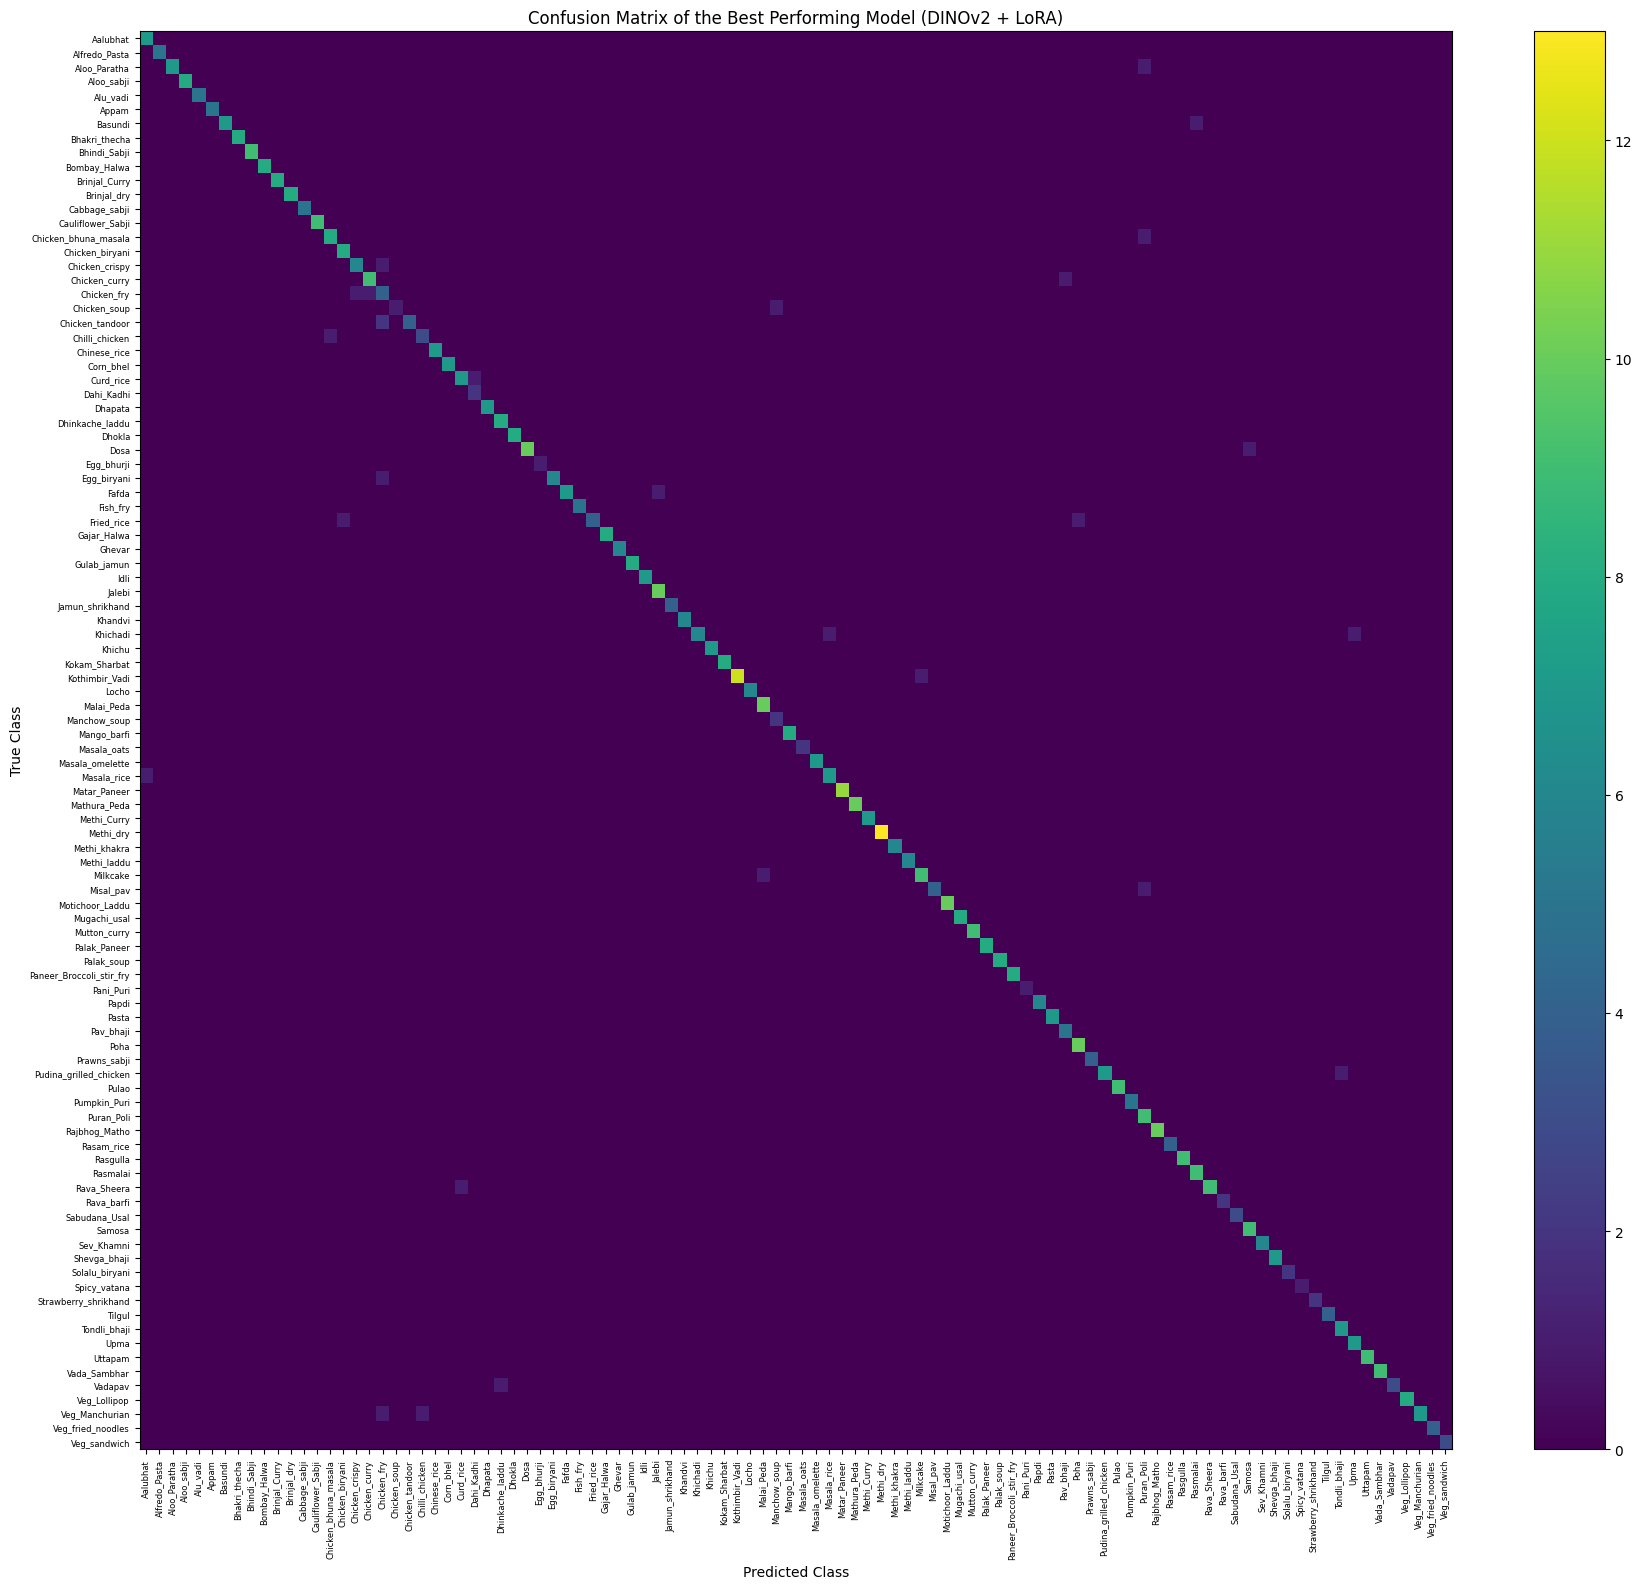

In [ ]:
# Target layers — lora_model uses PEFT wrapper prefix
lora_target_layer = lora_model.base_model.model.blocks[-1].norm1

print("Grad-CAM helpers ready ✓")
print(f"  ResNet target : model.layer4[-1]")
print(f"  LoRA target   : lora_model.base_model.model.blocks[-1].norm1")

eval_test_ds = TransformedSubset(full_ds, test_idx, eval_tf)

def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds = model(imgs).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

eval_test_loader = DataLoader(eval_test_ds, batch_size=32, shuffle=False, num_workers=2)
all_labels, all_preds = get_predictions(lora_model, eval_test_loader)
print(f"Generated predictions for {len(all_labels)} samples.")

from sklearn.metrics import confusion_matrix

y_true = all_labels
y_pred = all_preds
classes = class_names

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 16))
plt.imshow(cm, interpolation='nearest', aspect='auto')
plt.title("Confusion Matrix of the Best Performing Model (DINOv2 + LoRA)")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=90, fontsize=6)
plt.yticks(tick_marks, classes, fontsize=6)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.savefig(
    OUTPUTS_DIR / "confusion_matrix_best_model.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Collected 8 correctly classified samples.


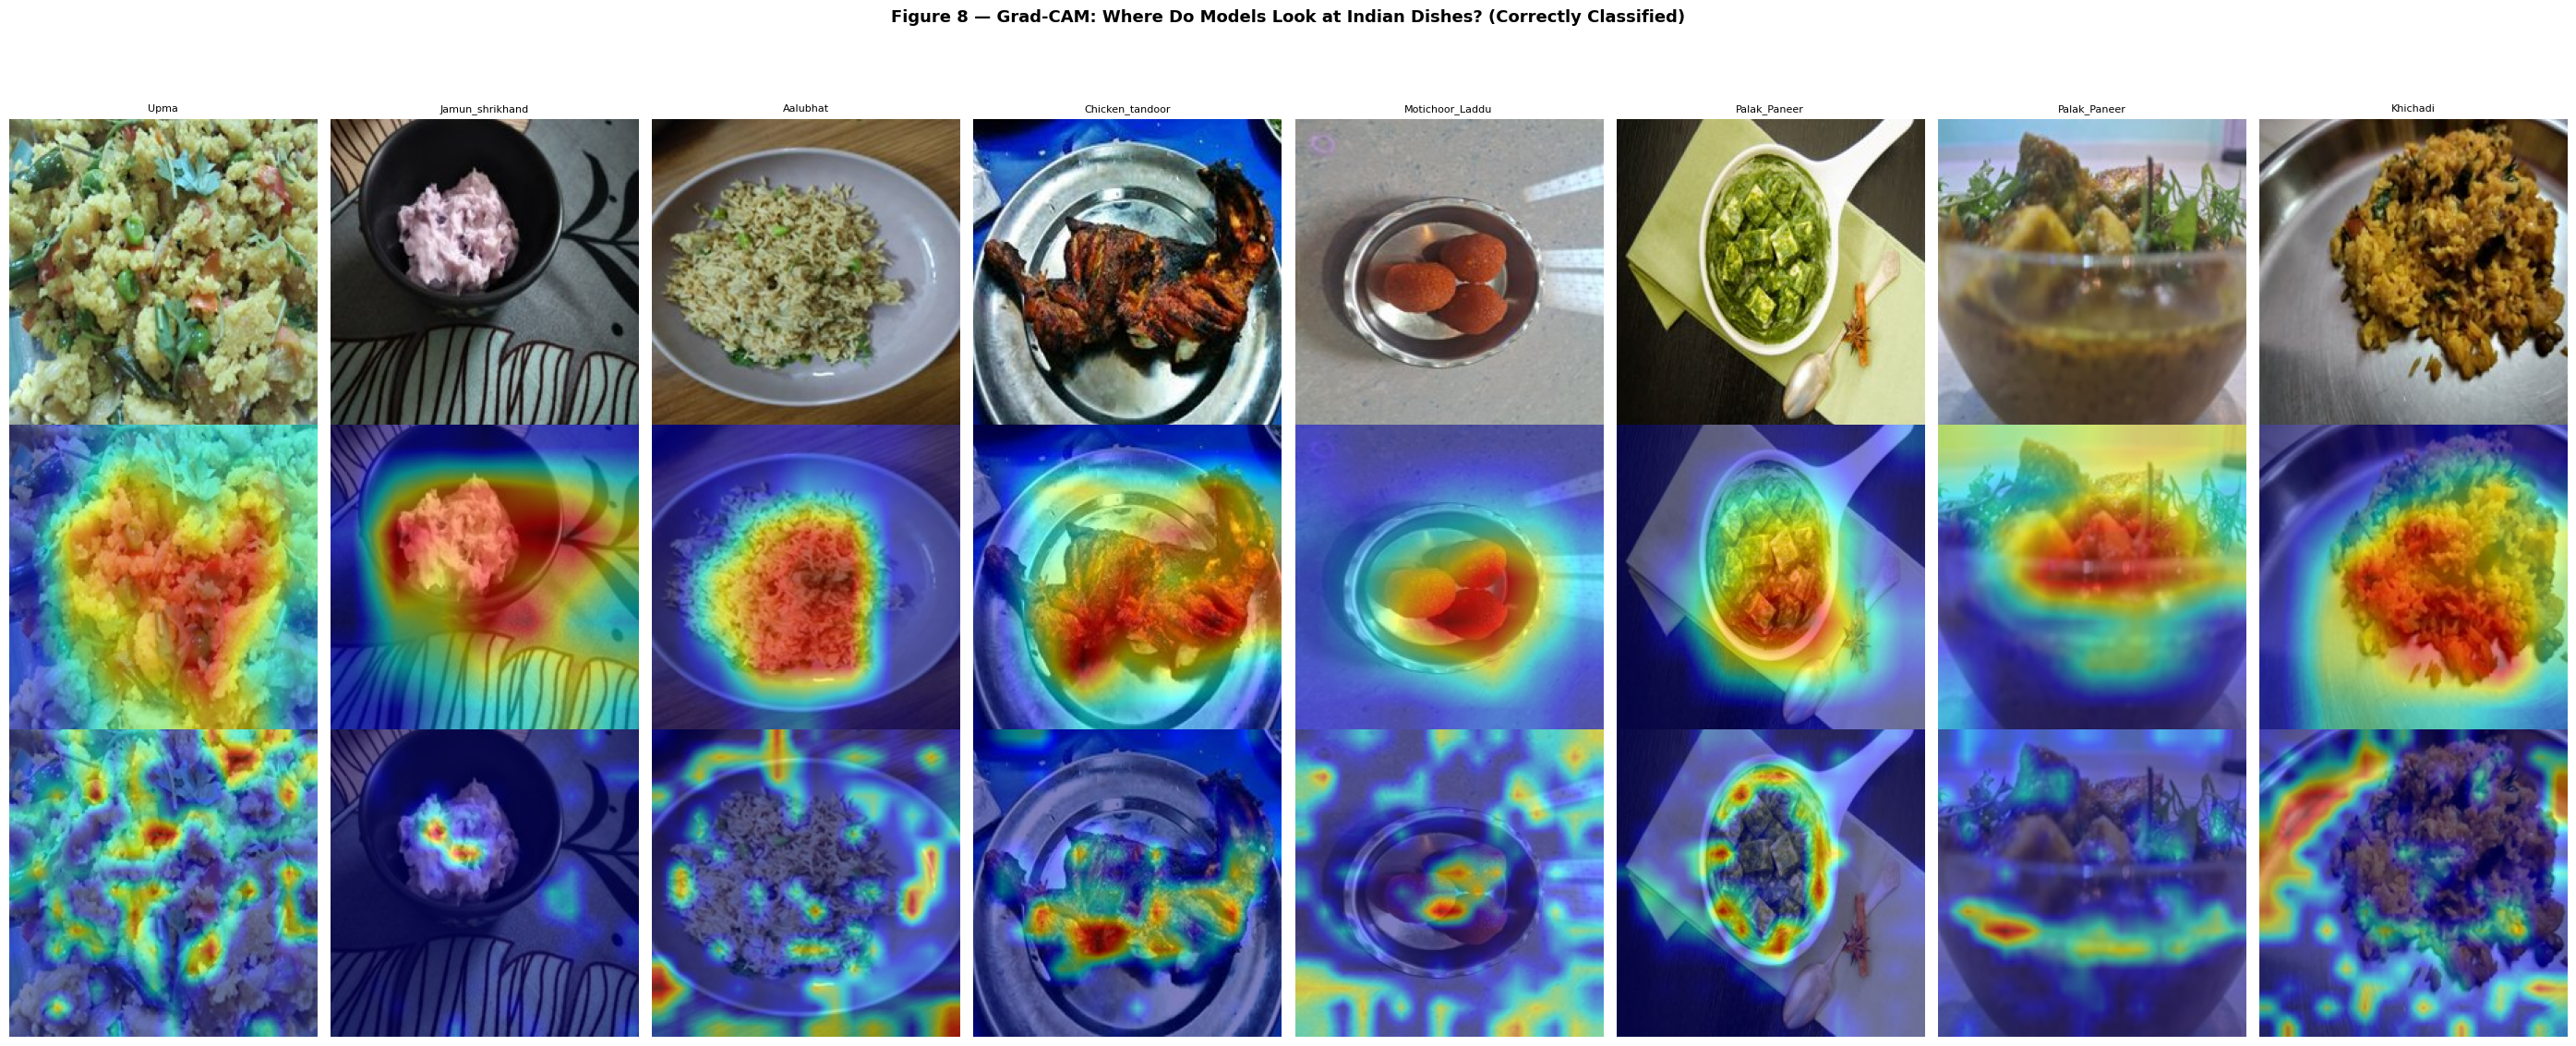

Figure 8 (correct predictions) saved ✓


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Collect correctly classified samples ────────────────────────────
eval_test_ds = TransformedSubset(full_ds, test_idx, eval_tf)
examples = []
for pos, global_idx in enumerate(test_idx):
    img, true_cls = eval_test_ds[pos]
    img_input = img.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_cls = lora_model(img_input).argmax(1).item()
    if pred_cls == true_cls:
        examples.append((img, true_cls, pred_cls, class_names[true_cls]))
    if len(examples) == 8:
        break
print(f"Collected {len(examples)} correctly classified samples.")

n_cols = len(examples) # Number of examples as columns
fig, axes = plt.subplots(3, n_cols, figsize=(n_cols * 3.5, 12)) # 3 rows (Original, ResNet, DINOv2), n_cols examples

# Row titles
row_titles = ["Original", "ResNet-50 Grad-CAM", "DINOv2 + LoRA Grad-CAM"]
for row_idx, title in enumerate(row_titles):
    axes[row_idx, 0].set_ylabel(title, fontsize=11, fontweight='bold', rotation=0, ha='right', va='center', labelpad=15) # Set on first column

for col, (img_t, true_cls, pred_cls, label) in enumerate(examples):
    rgb, cam_resnet = gradcam_resnet(resnet_model, img_t, pred_cls)
    _, cam_lora = gradcam_vit(lora_model, img_t, lora_target_layer, pred_cls)

    axes[0, col].imshow(rgb)
    axes[1, col].imshow(cam_resnet)
    axes[2, col].imshow(cam_lora)

    # Set example title on the top row
    axes[0, col].set_title(label.split('\n')[0], fontsize=8, pad=6)

    for row_idx in range(3):
        axes[row_idx, col].axis('off')

plt.suptitle('Figure 8 — Grad-CAM: Where Do Models Look at Indian Dishes? (Correctly Classified)',
              fontsize=13, fontweight='bold', y=0.95) # Adjust suptitle position
plt.tight_layout(rect=[0, 0, 1, 0.9]) # Adjust layout to make space for suptitle
plt.savefig(
    OUTPUTS_DIR / "figure27_gradcam_correct_predictions.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print("Figure 8 (correct predictions) saved ✓")

Collected 8 misclassified samples.


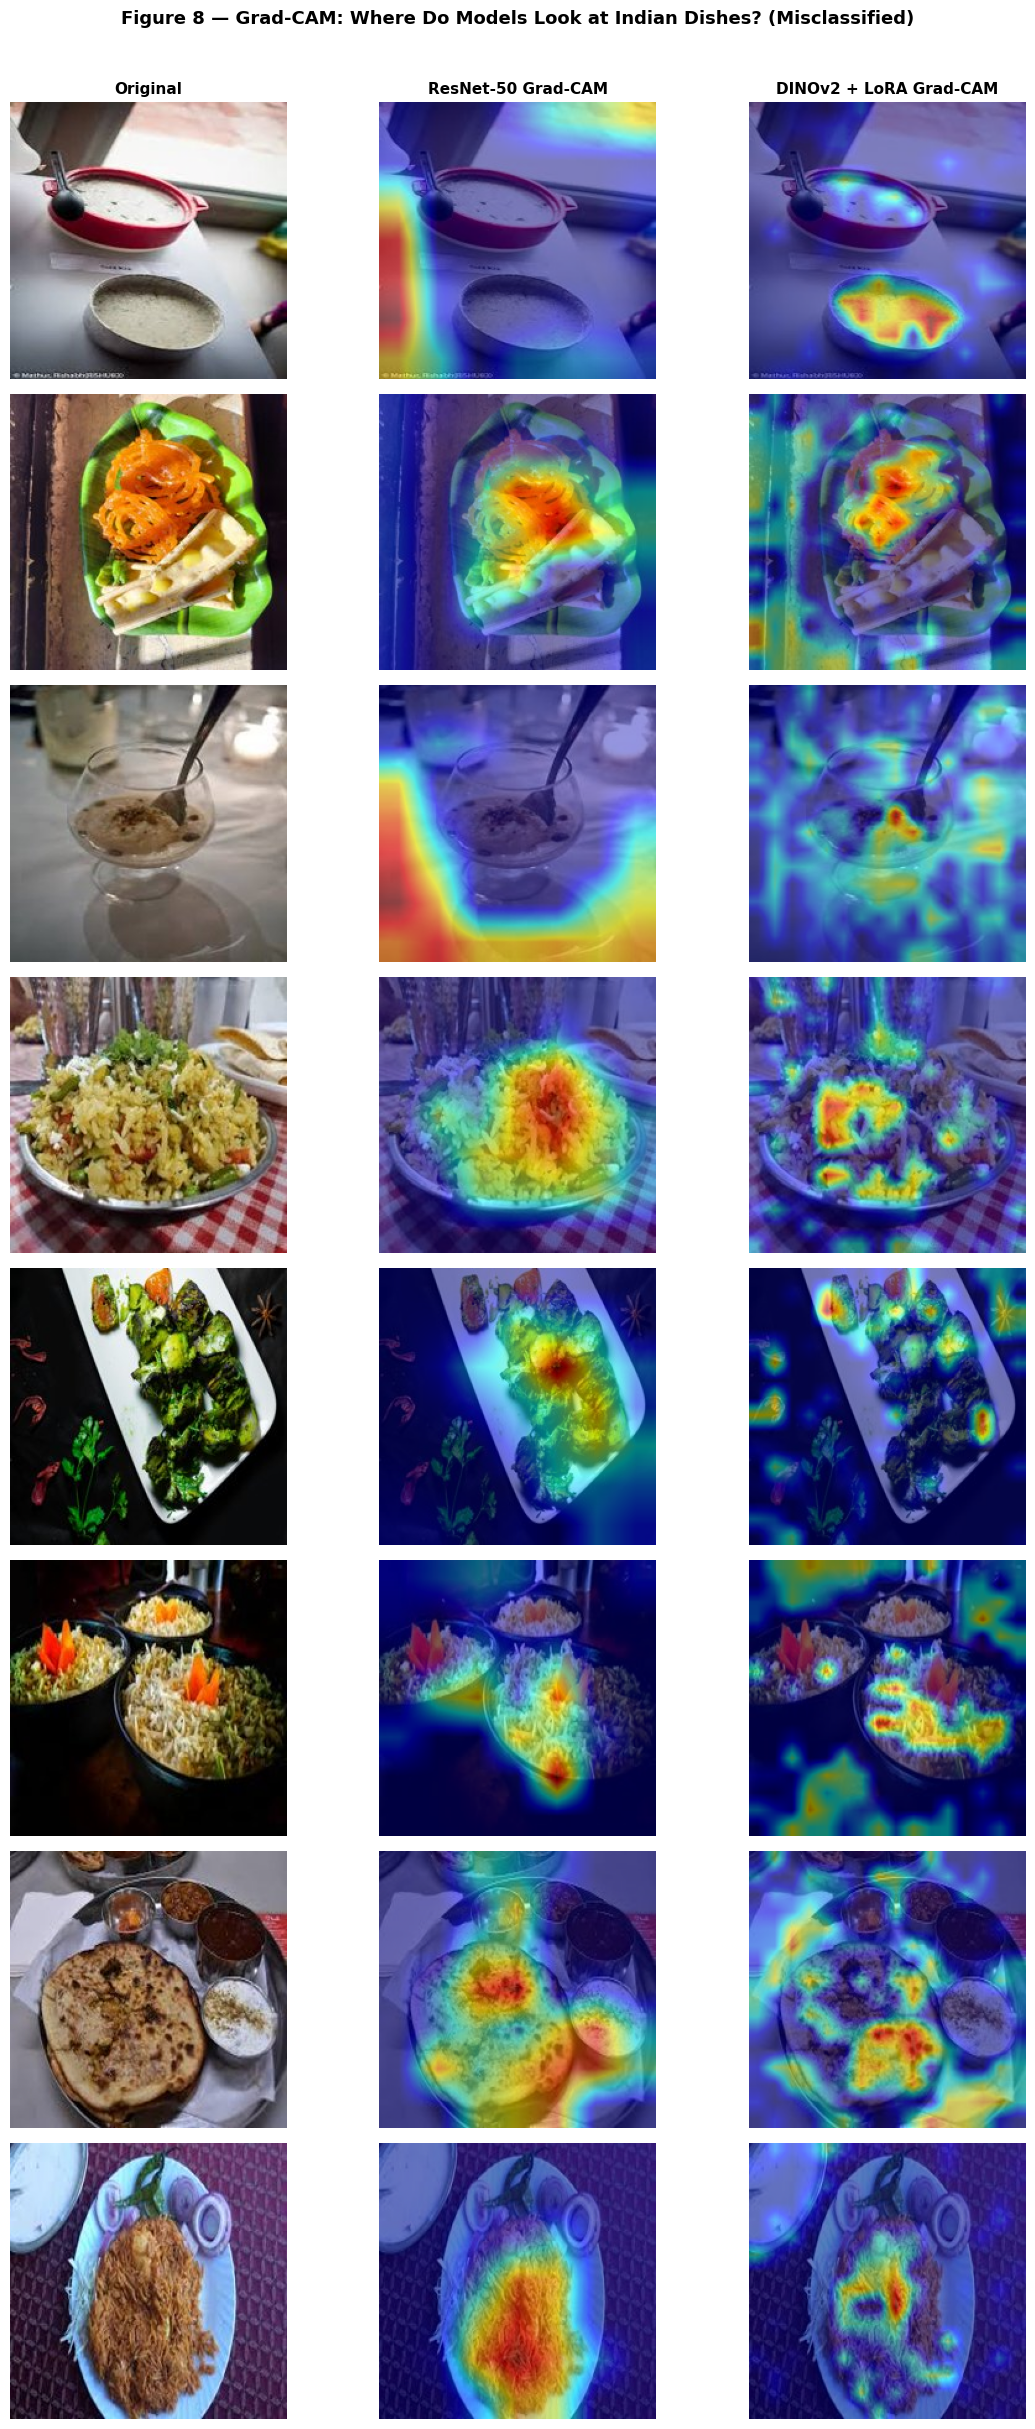

Figure 8 (misclassified) saved ✓


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ── Collect MISCLASSIFIED samples ───────────────────────────────────
eval_test_ds = TransformedSubset(full_ds, test_idx, eval_tf)
examples = []
for pos, global_idx in enumerate(test_idx):
    img, true_cls = eval_test_ds[pos]
    img_input = img.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        pred_cls = lora_model(img_input).argmax(1).item()
    if pred_cls != true_cls:
        examples.append((img, true_cls, pred_cls, class_names[true_cls], class_names[pred_cls]))
    if len(examples) == 8:
        break
print(f"Collected {len(examples)} misclassified samples.")

n_cols = len(examples) # Number of examples as columns
fig, axes = plt.subplots(3, n_cols, figsize=(n_cols * 3.5, 12)) # 3 rows (Original, ResNet, DINOv2), n_cols examples

# Row titles
row_titles = ["Original", "ResNet-50 Grad-CAM", "DINOv2 + LoRA Grad-CAM"]
for row_idx, title in enumerate(row_titles):
    axes[row_idx, 0].set_ylabel(title, fontsize=11, fontweight='bold', rotation=0, ha='right', va='center', labelpad=15) # Set on first column

for col, (img_t, true_cls, pred_cls, true_name, pred_name) in enumerate(examples):
    rgb, cam_resnet = gradcam_resnet(resnet_model, img_t, pred_cls)
    _, cam_lora = gradcam_vit(lora_model, img_t, lora_target_layer, pred_cls)

    axes[0, col].imshow(rgb)
    axes[1, col].imshow(cam_resnet)
    axes[2, col].imshow(cam_lora)

    # Set example title on the top row
    axes[0, col].set_title(f"True: {true_name.split('\n')[0]}\nPred: {pred_name.split('\n')[0]}", fontsize=8, pad=6)

    for row_idx in range(3):
        axes[row_idx, col].axis('off')

plt.suptitle('Figure 8 — Grad-CAM: Where Do Models Look at Indian Dishes? (Misclassified)',
              fontsize=13, fontweight='bold', y=0.95) # Adjust suptitle position
plt.tight_layout(rect=[0, 0, 1, 0.9]) # Adjust layout to make space for suptitle
plt.savefig(
    OUTPUTS_DIR / "figure28_gradcam_misclassified_predictions.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print("Figure 8 (misclassified) saved ✓")

In [ ]:
# ── Final checklist ──────────────────────────────────────────────────
checklist = {
    'splits/train_idx.pkl': SPLITS_DIR / 'train_idx.pkl',
    'splits/val_idx.pkl': SPLITS_DIR / 'val_idx.pkl',
    'splits/test_idx.pkl': SPLITS_DIR / 'test_idx.pkl',
    'outputs/table7_robustness.csv': OUTPUTS_DIR / 'table7_robustness.csv',
    'outputs/table7_accuracy_drop.csv': OUTPUTS_DIR / 'table7_accuracy_drop.csv',
    'outputs/table7_robustness_heatmap.pdf': OUTPUTS_DIR / 'table7_robustness_heatmap.pdf',
    'outputs/figure27_gradcam_correct_predictions.png': OUTPUTS_DIR / 'figure27_gradcam_correct_predictions.png',
    'outputs/figure28_gradcam_misclassified_predictions.png': OUTPUTS_DIR / 'figure28_gradcam_misclassified_predictions.png',
    'models/resnet50_scratch_100pct.pt': MODELS_DIR / 'resnet50_scratch_100pct.pt',
    'models/linear_probe_100pct.pt': MODELS_DIR / 'linear_probe_100pct.pt',
    'models/dinov2_lora_full.pth': MODELS_DIR / 'dinov2_lora_full.pth',
    'models/full_finetune_100pct.pt': MODELS_DIR / 'full_finetune_100pct.pt',
}